<a href="https://colab.research.google.com/github/Pranitha3197/PROJECTS/blob/main/CredResolve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import zipfile
import random
import time
import uuid
from pathlib import Path

from dataclasses import dataclass
from enum import Enum
from abc import ABC, abstractmethod
from datetime import datetime, timedelta

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
ZIP_PATH = "/content/collections_30k_dataset.zip"
EXTRACT_PATH = "collections_dataset"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
files = os.listdir(EXTRACT_PATH)

print("Files in dataset:\n")

for file in files:
    print(file)

Files in dataset:

call_attempts.csv
promises_to_pay.csv
call_dispositions.csv
accounts.csv
campaigns.csv
complaints.csv
agents.csv
README.md
daily_targeting.csv
vendor_telephony.csv
calls.csv
agent_sessions.csv
field_visits.csv
sms_events.csv
whatsapp_events.csv
account_status_history.csv
payments.csv
data_dictionary.csv
borrowers.csv


In [5]:
def load_csv(filename):
    path = os.path.join(EXTRACT_PATH, filename)
    df = pd.read_csv(path)

    print(f"\n{'='*60}")
    print(f"FILE: {filename}")
    print(f"SHAPE: {df.shape}")
    print(f"{'='*60}")

    display(df.head())

    return df

In [6]:
agents = load_csv("agents.csv")
agent_sessions = load_csv("agent_sessions.csv")
borrowers = load_csv("borrowers.csv")
accounts = load_csv("accounts.csv")
campaigns = load_csv("campaigns.csv")
daily_targeting = load_csv("daily_targeting.csv")
calls = load_csv("calls.csv")
call_attempts = load_csv("call_attempts.csv")
vendor_telephony = load_csv("vendor_telephony.csv")


FILE: agents.csv
SHAPE: (30000, 8)


,agent_id,employee_code,agent_name,vendor_id,team,status,joined_at,updated_at
0,AGT0000760,EMP00323,Vikram Shah,VND0000012,T3,INACTIVE,2025-06-19 20:30:53,2025-12-11 03:40:22
1,AGT0000171,EMP00079,Pooja Nair,VND0000012,T1,INACTIVE,2025-08-26 11:06:26,2025-10-11 08:30:33
2,AGT0000766,EMP00030,Sneha Das,VND0000002,FIELD,SUSPENDED,2024-05-30 11:23:06,2026-05-16 03:02:02
3,AGT0000031,EMP00334,Aarav Sharma,VND0000007,T1,INACTIVE,2024-10-11 18:58:28,2025-10-16 13:31:21
4,AGT0000669,EMP00014,Aarav Sharma,VND0000001,T3,SUSPENDED,2024-09-01 19:55:06,2026-07-04 03:33:11



FILE: agent_sessions.csv
SHAPE: (15000, 7)


,session_id,agent_id,login_at,channel,device_id,timezone,logout_at
0,SES0000001,AGT0000117,2026-08-06 13:33:27,VOICE,DEV00243,Asia/Kolkata,2026-08-06 18:41:13
1,SES0000002,AGT0000847,2026-05-27 02:02:28,FIELD,DEV01359,UTC,2026-05-27 09:02:31
2,SES0000003,AGT0000989,2026-08-01 20:33:44,FIELD,DEV01432,Asia/Kolkata,2026-08-02 05:53:43
3,SES0000004,AGT0000961,2026-01-13 19:50:52,FIELD,DEV00402,Asia/Kolkata,2026-01-13 22:20:49
4,SES0000005,AGT0000280,2026-03-03 15:05:04,VOICE,DEV01288,UTC,2026-03-03 18:19:09



FILE: borrowers.csv
SHAPE: (30600, 8)


...

,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone
0,CALL0000001,ACC0011505,BRW0007139,2026-07-15 15:36:22,AGT0000955,CMP0000015,OUTBOUND,VND0000013,NO_ANSWER,601,Asia/Dubai
1,CALL0000002,ACC0002025,BRW0006253,2026-06-10 06:48:27,AGT0000853,CMP0000060,OUTBOUND,VND0000001,ANSWERED,224,Asia/Kolkata
2,CALL0000003,ACC0013375,BRW0007663,2026-04-07 00:35:35,AGT0000525,CMP0000060,OUTBOUND,VND0000008,FAILED,7,Asia/Dubai
3,CALL0000004,ACC0021534,BRW0008873,2026-02-12 14:16:57,AGT0000945,CMP0000060,OUTBOUND,VND0000001,VOICEMAIL,896,Asia/Dubai
4,CALL0000005,ACC0018502,BRW0004996,2026-05-24 15:33:12,AGT0000966,CMP0000053,OUTBOUND,VND0000006,ANSWERED,711,Asia/Kolkata



FILE: call_attempts.csv
SHAPE: (120000, 9)


,attempt_id,account_id,borrower_id,event_at,call_id,agent_id,attempt_no,vendor_id,attempt_status
0,ATTEMPT0000001,ACC0009527,BRW0000705,2026-03-10 21:31:13,CALL0019052,AGT0000685,5,VND0000013,FAILED
1,ATTEMPT0000002,ACC0007960,BRW0002732,2026-05-01 20:55:02,CALL0011950,AGT0000472,4,VND0000006,CONNECTED
2,ATTEMPT0000003,ACC0016476,BRW0002174,2026-06-05 20:57:37,CALL0017411,AGT0000035,1,VND0000015,RINGING
3,ATTEMPT0000004,ACC0011111,BRW0003738,2026-05-02 06:08:39,CALL0068999,AGT0000277,3,VND0000010,FAILED
4,ATTEMPT0000005,ACC0010343,BRW0003352,2026-05-27 03:48:23,CALL0049585,AGT0000346,5,VND0000008,CONNECTED



FILE: vendor_telephony.csv
SHAPE: (15, 6)


,vendor_id,vendor_name,vendor_account_id,timezone,status,schema_version
0,VND0000001,Airtel,VAC342762,Asia/Kolkata,INACTIVE,v3
1,VND0000002,Exotel,VAC456766,UTC,INACTIVE,v3
2,VND0000003,Twilio,VAC074211,UTC,INACTIVE,v3
3,VND0000004,Twilio,VAC321507,UTC,ACTIVE,v1
4,VND0000005,Twilio,VAC976733,Asia/Kolkata,ACTIVE,v1


In [7]:
def inspect_dataframe(df, name):
    print(f"\n{'='*70}")
    print(f"DATASET: {name}")
    print(f"{'='*70}")

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

In [8]:
inspect_dataframe(agents, "AGENTS")
inspect_dataframe(agent_sessions, "AGENT SESSIONS")
inspect_dataframe(calls, "CALLS")
inspect_dataframe(call_attempts, "CALL ATTEMPTS")


DATASET: AGENTS

Shape:
(30000, 8)

Columns:
['agent_id', 'employee_code', 'agent_name', 'vendor_id', 'team', 'status', 'joined_at', 'updated_at']

Data Types:
agent_id         object
employee_code    object
agent_name       object
vendor_id        object
team             object
status           object
joined_at        object
updated_at       object
dtype: object

Missing Values:
agent_id         0
employee_code    0
agent_name       0
vendor_id        0
team             0
status           0
joined_at        0
updated_at       0
dtype: int64

Duplicate Rows:
0

DATASET: AGENT SESSIONS

Shape:
(15000, 7)

Columns:
['session_id', 'agent_id', 'login_at', 'channel', 'device_id', 'timezone', 'logout_at']

Data Types:
session_id    object
agent_id      object
login_at      object
channel       object
device_id     object
timezone      object
logout_at     object
dtype: object

Missing Values:
session_id    0
agent_id      0
login_at      0
channel       0
device_id     0
timezone      0
log

In [9]:
agents_clean = agents.drop_duplicates().copy()
calls_clean = calls.drop_duplicates().copy()
call_attempts_clean = call_attempts.drop_duplicates().copy()

print("Raw agents:", len(agents))
print("Clean agents:", len(agents_clean))

print("\nRaw calls:", len(calls))
print("Clean calls:", len(calls_clean))

print("\nRaw call attempts:", len(call_attempts))
print("Clean call attempts:", len(call_attempts_clean))

Raw agents: 30000
Clean agents: 30000

Raw calls: 91350
Clean calls: 90079

Raw call attempts: 120000
Clean call attempts: 120000


In [10]:
datasets = {
    "agents": agents,
    "agent_sessions": agent_sessions,
    "borrowers": borrowers,
    "accounts": accounts,
    "campaigns": campaigns,
    "daily_targeting": daily_targeting,
    "calls": calls,
    "call_attempts": call_attempts,
    "vendor_telephony": vendor_telephony
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.columns.tolist())


AGENTS
['agent_id', 'employee_code', 'agent_name', 'vendor_id', 'team', 'status', 'joined_at', 'updated_at']

AGENT_SESSIONS
['session_id', 'agent_id', 'login_at', 'channel', 'device_id', 'timezone', 'logout_at']

BORROWERS
['borrower_id', 'name', 'phone', 'email', 'city', 'created_at', 'updated_at', 'state']

ACCOUNTS
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version']

CAMPAIGNS
['campaign_id', 'campaign_name', 'channel', 'strategy_version', 'start_at', 'target_definition', 'end_at']

DAILY_TARGETING
['target_id', 'account_id', 'campaign_id', 'target_date', 'priority', 'recommended_channel', 'status']

CALLS
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone']

CALL_ATTEMPTS
['attempt_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'attempt_no', 'vendor_id', 'a

In [11]:
for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(f"{name.upper()} DATA QUALITY REPORT")
    print("=" * 80)

    print("\nTotal Rows:", len(df))
    print("Duplicate Rows:", df.duplicated().sum())

    print("\nMissing Values:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

    print()


AGENTS DATA QUALITY REPORT

Total Rows: 30000
Duplicate Rows: 0

Missing Values:
No missing values


AGENT_SESSIONS DATA QUALITY REPORT

Total Rows: 15000
Duplicate Rows: 0

Missing Values:
No missing values


BORROWERS DATA QUALITY REPORT

Total Rows: 30600
Duplicate Rows: 600

Missing Values:
phone    614
email    895
dtype: int64


ACCOUNTS DATA QUALITY REPORT

Total Rows: 30000
Duplicate Rows: 0

Missing Values:
borrower_id    455
dtype: int64


CAMPAIGNS DATA QUALITY REPORT

Total Rows: 120
Duplicate Rows: 0

Missing Values:
No missing values


DAILY_TARGETING DATA QUALITY REPORT

Total Rows: 45000
Duplicate Rows: 0

Missing Values:
No missing values


CALLS DATA QUALITY REPORT

Total Rows: 91350
Duplicate Rows: 1271

Missing Values:
agent_id    1827
dtype: int64


CALL_ATTEMPTS DATA QUALITY REPORT

Total Rows: 120000
Duplicate Rows: 0

Missing Values:
vendor_id    2400
dtype: int64


VENDOR_TELEPHONY DATA QUALITY REPORT

Total Rows: 15
Duplicate Rows: 0

Missing Values:
No missi

In [12]:
agents_clean = agents.drop_duplicates().copy()
agent_sessions_clean = agent_sessions.drop_duplicates().copy()
borrowers_clean = borrowers.drop_duplicates().copy()
accounts_clean = accounts.drop_duplicates().copy()
campaigns_clean = campaigns.drop_duplicates().copy()
daily_targeting_clean = daily_targeting.drop_duplicates().copy()
calls_clean = calls.drop_duplicates().copy()
call_attempts_clean = call_attempts.drop_duplicates().copy()
vendor_telephony_clean = vendor_telephony.drop_duplicates().copy()

print("Clean copies created successfully!")

Clean copies created successfully!


In [13]:
date_columns = {
    "agents": ["joined_at", "updated_at"],
    "agent_sessions": ["login_at", "logout_at"],
    "borrowers": ["created_at", "updated_at"],
    "accounts": ["opened_at"],
    "campaigns": ["start_at", "end_at"],
    "daily_targeting": ["target_date"],
    "calls": ["event_at"]
}

clean_datasets = {
    "agents": agents_clean,
    "agent_sessions": agent_sessions_clean,
    "borrowers": borrowers_clean,
    "accounts": accounts_clean,
    "campaigns": campaigns_clean,
    "daily_targeting": daily_targeting_clean,
    "calls": calls_clean
}

for dataset_name, columns in date_columns.items():
    df = clean_datasets[dataset_name]

    for column in columns:
        if column in df.columns:
            df[column] = pd.to_datetime(
                df[column],
                errors="coerce",
                utc=True
            )

print("Date columns normalized successfully!")

Date columns normalized successfully!


AGENT STATUS DISTRIBUTION
--------------------------------------------------
status
ACTIVE       10083
INACTIVE     10066
SUSPENDED     9851
Name: count, dtype: int64


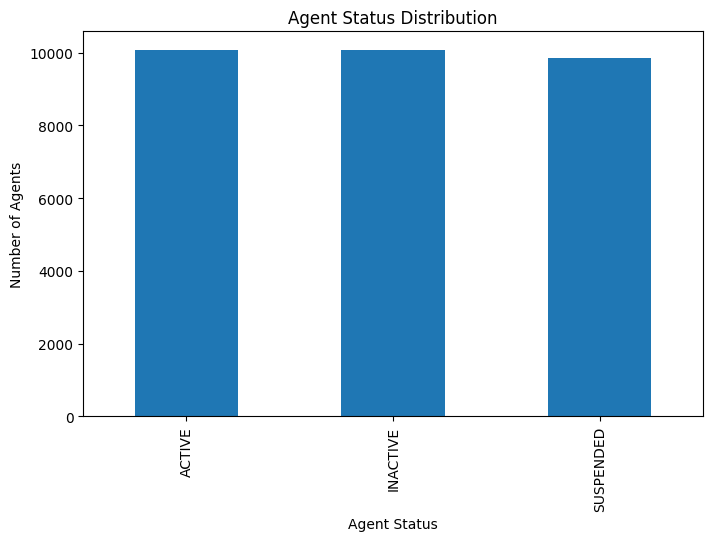

In [14]:
print("AGENT STATUS DISTRIBUTION")
print("-" * 50)

agent_status_counts = agents_clean["status"].value_counts(dropna=False)

print(agent_status_counts)

plt.figure(figsize=(8, 5))
agent_status_counts.plot(kind="bar")

plt.title("Agent Status Distribution")
plt.xlabel("Agent Status")
plt.ylabel("Number of Agents")

plt.show()

In [15]:
print("Unique Agent Statuses:")
print(agents_clean["status"].unique())

Unique Agent Statuses:
['INACTIVE' 'SUSPENDED' 'ACTIVE']


In [16]:
agents_clean["status_normalized"] = (
    agents_clean["status"]
    .astype(str)
    .str.upper()
    .str.strip()
)

available_agents_df = agents_clean[
    agents_clean["status_normalized"] == "AVAILABLE"
].copy()

available_agent_count = len(available_agents_df)

print(f"Total Agents: {len(agents_clean)}")
print(f"Available Agents: {available_agent_count}")

Total Agents: 30000
Available Agents: 0


CALL STATUS DISTRIBUTION
--------------------------------------------------
call_status
NO_ANSWER    18092
BUSY         18078
FAILED       18014
VOICEMAIL    17999
ANSWERED     17896
Name: count, dtype: int64


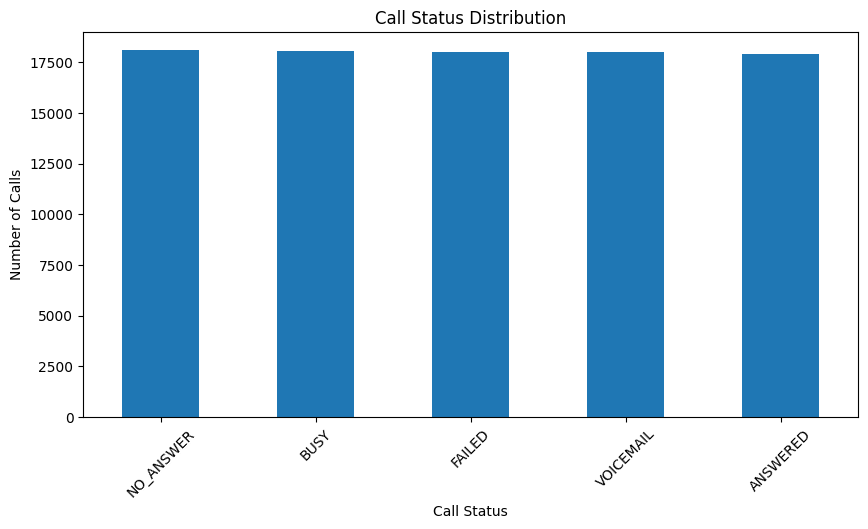

In [17]:
print("CALL STATUS DISTRIBUTION")
print("-" * 50)

call_status_counts = (
    calls_clean["call_status"]
    .astype(str)
    .str.upper()
    .value_counts()
)

print(call_status_counts)

plt.figure(figsize=(10, 5))
call_status_counts.plot(kind="bar")

plt.title("Call Status Distribution")
plt.xlabel("Call Status")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.show()

In [18]:
print("CALL ATTEMPT STATUS DISTRIBUTION")
print("-" * 50)

attempt_status_counts = (
    call_attempts_clean["attempt_status"]
    .astype(str)
    .str.upper()
    .value_counts()
)

print(attempt_status_counts)

CALL ATTEMPT STATUS DISTRIBUTION
--------------------------------------------------
attempt_status
RINGING      24087
NO_ANSWER    24042
BUSY         24037
CONNECTED    24023
FAILED       23811
Name: count, dtype: int64


In [19]:
total_calls = len(calls_clean)

calls_with_duration = calls_clean[
    calls_clean["duration_sec"].notna()
].copy()

average_talk_time = calls_with_duration["duration_sec"].mean()

print("=" * 60)
print("HISTORICAL CALL METRICS")
print("=" * 60)

print(f"Total Calls: {total_calls:,}")
print(f"Calls with Duration: {len(calls_with_duration):,}")
print(f"Average Call Duration: {average_talk_time:.2f} seconds")

HISTORICAL CALL METRICS
Total Calls: 90,079
Calls with Duration: 90,079
Average Call Duration: 451.03 seconds


VENDOR DISTRIBUTION
--------------------------------------------------
vendor_id
VND0000010    6167
VND0000011    6078
VND0000007    6074
VND0000015    6071
VND0000005    6055
VND0000014    6046
VND0000001    6031
VND0000012    6015
VND0000009    5976
VND0000003    5966
VND0000002    5941
VND0000004    5930
VND0000008    5917
VND0000013    5909
VND0000006    5903
Name: count, dtype: int64


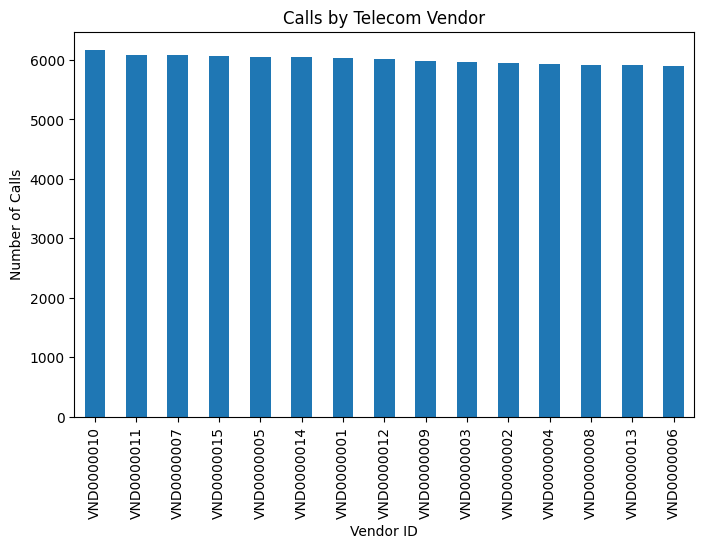

In [20]:
print("VENDOR DISTRIBUTION")
print("-" * 50)

vendor_counts = calls_clean["vendor_id"].value_counts(dropna=False)

print(vendor_counts)

plt.figure(figsize=(8, 5))
vendor_counts.plot(kind="bar")

plt.title("Calls by Telecom Vendor")
plt.xlabel("Vendor ID")
plt.ylabel("Number of Calls")

plt.show()

In [21]:
from enum import Enum


class AgentState(str, Enum):
    OFFLINE = "OFFLINE"
    AVAILABLE = "AVAILABLE"
    RESERVED = "RESERVED"
    DIALING = "DIALING"
    CONNECTED = "CONNECTED"
    WRAP_UP = "WRAP_UP"
    PAUSED = "PAUSED"


VALID_AGENT_TRANSITIONS = {
    AgentState.OFFLINE: {
        AgentState.AVAILABLE
    },

    AgentState.AVAILABLE: {
        AgentState.RESERVED,
        AgentState.PAUSED,
        AgentState.OFFLINE
    },

    AgentState.RESERVED: {
        AgentState.DIALING,
        AgentState.AVAILABLE,
        AgentState.OFFLINE
    },

    AgentState.DIALING: {
        AgentState.CONNECTED,
        AgentState.AVAILABLE,
        AgentState.OFFLINE
    },

    AgentState.CONNECTED: {
        AgentState.WRAP_UP,
        AgentState.OFFLINE
    },

    AgentState.WRAP_UP: {
        AgentState.AVAILABLE,
        AgentState.PAUSED,
        AgentState.OFFLINE
    },

    AgentState.PAUSED: {
        AgentState.AVAILABLE,
        AgentState.OFFLINE
    }
}


def is_valid_agent_transition(current_state, new_state):
    return new_state in VALID_AGENT_TRANSITIONS.get(current_state, set())


print("Agent State Machine created successfully!")

Agent State Machine created successfully!


In [22]:
test_transitions = [
    (AgentState.AVAILABLE, AgentState.RESERVED),
    (AgentState.RESERVED, AgentState.DIALING),
    (AgentState.CONNECTED, AgentState.WRAP_UP),
    (AgentState.WRAP_UP, AgentState.AVAILABLE),
    (AgentState.CONNECTED, AgentState.RESERVED)
]

for current_state, new_state in test_transitions:
    result = is_valid_agent_transition(current_state, new_state)

    print(
        f"{current_state.value} -> "
        f"{new_state.value}: "
        f"{'VALID' if result else 'INVALID'}"
    )

AVAILABLE -> RESERVED: VALID
RESERVED -> DIALING: VALID
CONNECTED -> WRAP_UP: VALID
WRAP_UP -> AVAILABLE: VALID
CONNECTED -> RESERVED: INVALID


In [23]:
class CallState(str, Enum):
    QUEUED = "QUEUED"
    RESERVED = "RESERVED"
    INITIATED = "INITIATED"
    RINGING = "RINGING"
    ANSWERED = "ANSWERED"
    CONNECTED = "CONNECTED"
    COMPLETED = "COMPLETED"
    FAILED = "FAILED"
    CANCELLED = "CANCELLED"

In [24]:
VALID_CALL_TRANSITIONS = {

    CallState.QUEUED: {
        CallState.RESERVED,
        CallState.CANCELLED
    },

    CallState.RESERVED: {
        CallState.INITIATED,
        CallState.CANCELLED,
        CallState.FAILED
    },

    CallState.INITIATED: {
        CallState.RINGING,
        CallState.ANSWERED,
        CallState.FAILED,
        CallState.CANCELLED
    },

    CallState.RINGING: {
        CallState.ANSWERED,
        CallState.CONNECTED,
        CallState.FAILED,
        CallState.CANCELLED
    },

    CallState.ANSWERED: {
        CallState.CONNECTED,
        CallState.COMPLETED
    },

    CallState.CONNECTED: {
        CallState.COMPLETED,
        CallState.FAILED
    },

    CallState.COMPLETED: set(),
    CallState.FAILED: set(),
    CallState.CANCELLED: set()
}


def is_valid_call_transition(current_state, new_state):
    return new_state in VALID_CALL_TRANSITIONS.get(current_state, set())


print("Call State Machine created successfully!")

Call State Machine created successfully!


In [25]:
CALL_STATE_RANK = {
    CallState.QUEUED: 0,
    CallState.RESERVED: 1,
    CallState.INITIATED: 2,
    CallState.RINGING: 3,
    CallState.ANSWERED: 4,
    CallState.CONNECTED: 5,
    CallState.COMPLETED: 6
}


TERMINAL_CALL_STATES = {
    CallState.COMPLETED,
    CallState.FAILED,
    CallState.CANCELLED
}


def should_apply_call_event(current_state, incoming_state):

    # Terminal states never move backwards
    if current_state in TERMINAL_CALL_STATES:
        return False

    # Failure and cancellation are terminal
    if incoming_state in {
        CallState.FAILED,
        CallState.CANCELLED
    }:
        return True

    # Ignore backward events
    current_rank = CALL_STATE_RANK.get(current_state, -1)
    incoming_rank = CALL_STATE_RANK.get(incoming_state, -1)

    return incoming_rank > current_rank


print("Out-of-order event protection created successfully!")

Out-of-order event protection created successfully!


In [26]:
current_state = CallState.COMPLETED

incoming_events = [
    CallState.ANSWERED,
    CallState.RINGING,
    CallState.COMPLETED
]

print("Current State:", current_state.value)
print("-" * 40)

for incoming_state in incoming_events:

    apply_event = should_apply_call_event(
        current_state,
        incoming_state
    )

    print(
        f"Incoming Event: {incoming_state.value} | "
        f"{'APPLY' if apply_event else 'IGNORE'}"
    )

Current State: COMPLETED
----------------------------------------
Incoming Event: ANSWERED | IGNORE
Incoming Event: RINGING | IGNORE
Incoming Event: COMPLETED | IGNORE


In [27]:
@dataclass
class DialerAgent:
    agent_id: str
    state: AgentState = AgentState.AVAILABLE
    reservation_id: str = None
    reserved_until: datetime = None

    def is_available(self):
        return self.state == AgentState.AVAILABLE

In [28]:
@dataclass
class DialerCall:
    call_id: str
    borrower_id: str
    account_id: str
    agent_id: str = None

    state: CallState = CallState.QUEUED

    provider_call_id: str = None
    provider_id: str = None

    created_at: datetime = None
    updated_at: datetime = None

    def __post_init__(self):

        if self.created_at is None:
            self.created_at = datetime.now()

        if self.updated_at is None:
            self.updated_at = self.created_at

In [29]:
SIMULATION_AGENT_COUNT = min(100, len(agents_clean))

simulation_agents = {}

for agent_id in agents_clean["agent_id"].head(SIMULATION_AGENT_COUNT):

    simulation_agents[str(agent_id)] = DialerAgent(
        agent_id=str(agent_id),
        state=AgentState.AVAILABLE
    )


print(
    f"{len(simulation_agents)} simulation agents "
    f"created successfully!"
)

96 simulation agents created successfully!


In [30]:
for i, agent in enumerate(simulation_agents.values()):

    print(
        agent.agent_id,
        "|",
        agent.state.value
    )

    if i >= 9:
        break

AGT0000760 | AVAILABLE
AGT0000171 | AVAILABLE
AGT0000766 | AVAILABLE
AGT0000031 | AVAILABLE
AGT0000669 | AVAILABLE
AGT0000968 | AVAILABLE
AGT0000155 | AVAILABLE
AGT0000480 | AVAILABLE
AGT0000404 | AVAILABLE
AGT0000077 | AVAILABLE


In [31]:
import threading


class AgentAllocator:

    def __init__(self, agents):
        self.agents = agents
        self.lock = threading.Lock()

    def reserve_agent(self, worker_id):

        # Only one worker can enter this critical section at a time
        with self.lock:

            for agent in self.agents.values():

                if agent.state == AgentState.AVAILABLE:

                    reservation_id = str(uuid.uuid4())

                    agent.state = AgentState.RESERVED
                    agent.reservation_id = reservation_id
                    agent.reserved_until = (
                        datetime.now() + timedelta(seconds=30)
                    )

                    print(
                        f"Worker {worker_id} reserved "
                        f"Agent {agent.agent_id}"
                    )

                    return agent

            print(f"Worker {worker_id}: No agent available")

            return None


    def release_agent(self, agent_id):

        with self.lock:

            agent = self.agents.get(str(agent_id))

            if agent is None:
                return False

            if agent.state in {
                AgentState.RESERVED,
                AgentState.DIALING
            }:

                agent.state = AgentState.AVAILABLE
                agent.reservation_id = None
                agent.reserved_until = None

                return True

            return False


agent_allocator = AgentAllocator(simulation_agents)

print("Atomic Agent Allocator created successfully!")

Atomic Agent Allocator created successfully!


In [32]:
reserved_agent = agent_allocator.reserve_agent(
    worker_id="WORKER_1"
)

if reserved_agent:

    print("\nReservation Successful")
    print("Agent ID:", reserved_agent.agent_id)
    print("State:", reserved_agent.state.value)
    print("Reservation ID:", reserved_agent.reservation_id)
    print("Reserved Until:", reserved_agent.reserved_until)

Worker WORKER_1 reserved Agent AGT0000760

Reservation Successful
Agent ID: AGT0000760
State: RESERVED
Reservation ID: 8465735b-cb0d-4ed8-85de-e8f796695821
Reserved Until: 2026-08-21 10:52:30.929905


In [33]:
if reserved_agent:

    released = agent_allocator.release_agent(
        reserved_agent.agent_id
    )

    print(
        f"Agent {reserved_agent.agent_id} released: "
        f"{released}"
    )

    print(
        "Current State:",
        simulation_agents[
            reserved_agent.agent_id
        ].state.value
    )

Agent AGT0000760 released: True
Current State: AVAILABLE


In [34]:
def worker_reservation_test(worker_id):

    agent = agent_allocator.reserve_agent(worker_id)

    if agent:

        print(
            f"SUCCESS -> {worker_id} got "
            f"{agent.agent_id}"
        )

    else:

        print(
            f"FAILED -> {worker_id} got no agent"
        )

In [35]:
threads = []

NUMBER_OF_WORKERS = 10


for i in range(NUMBER_OF_WORKERS):

    worker_id = f"WORKER_{i + 1}"

    thread = threading.Thread(
        target=worker_reservation_test,
        args=(worker_id,)
    )

    threads.append(thread)
    thread.start()


for thread in threads:
    thread.join()


print("\nAll workers completed!")

Worker WORKER_1 reserved Agent AGT0000760
SUCCESS -> WORKER_1 got AGT0000760
Worker WORKER_2 reserved Agent AGT0000171
SUCCESS -> WORKER_2 got AGT0000171
Worker WORKER_3 reserved Agent AGT0000766
SUCCESS -> WORKER_3 got AGT0000766
Worker WORKER_4 reserved Agent AGT0000031
SUCCESS -> WORKER_4 got AGT0000031
Worker WORKER_5 reserved Agent AGT0000669
SUCCESS -> WORKER_5 got AGT0000669
Worker WORKER_6 reserved Agent AGT0000968
SUCCESS -> WORKER_6 got AGT0000968
Worker WORKER_7 reserved Agent AGT0000155
SUCCESS -> WORKER_7 got AGT0000155
Worker WORKER_8 reserved Agent AGT0000480
SUCCESS -> WORKER_8 got AGT0000480
Worker WORKER_9 reserved Agent AGT0000404
SUCCESS -> WORKER_9 got AGT0000404
Worker WORKER_10 reserved Agent AGT0000077
SUCCESS -> WORKER_10 got AGT0000077

All workers completed!


In [36]:
reserved_agents = [
    agent
    for agent in simulation_agents.values()
    if agent.state == AgentState.RESERVED
]


reserved_agent_ids = [
    agent.agent_id
    for agent in reserved_agents
]


print("Total Reserved Agents:", len(reserved_agent_ids))
print(
    "Unique Reserved Agents:",
    len(set(reserved_agent_ids))
)


if len(reserved_agent_ids) == len(set(reserved_agent_ids)):

    print(
        "\nSUCCESS: No agent was allocated twice!"
    )

else:

    print(
        "\nERROR: Duplicate agent allocation detected!"
    )

Total Reserved Agents: 10
Unique Reserved Agents: 10

SUCCESS: No agent was allocated twice!


In [37]:
target_queue = (
    daily_targeting_clean
    .copy()
    .sort_values(
        by="priority",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Total targets:", len(target_queue))

display(
    target_queue[
        [
            "account_id",
            "campaign_id",
            "priority",
            "recommended_channel",
            "status"
        ]
    ].head(10)
)

Total targets: 45000


,account_id,campaign_id,priority,recommended_channel,status
0,ACC0012329,CMP0000046,10,WHATSAPP,QUEUED
1,ACC0007194,CMP0000100,10,SMS,EXPIRED
2,ACC0003190,CMP0000119,10,VOICE,CONTACTED
3,ACC0005262,CMP0000002,10,VOICE,QUEUED
4,ACC0016879,CMP0000097,10,VOICE,EXPIRED
5,ACC0022796,CMP0000105,10,WHATSAPP,QUEUED
6,ACC0027727,CMP0000111,10,WHATSAPP,SKIPPED
7,ACC0001593,CMP0000114,10,FIELD,SKIPPED
8,ACC0029200,CMP0000050,10,VOICE,QUEUED
9,ACC0014823,CMP0000119,10,FIELD,CONTACTED


In [38]:
print(
    target_queue[
        "recommended_channel"
    ]
    .value_counts(dropna=False)
)

recommended_channel
FIELD       11365
SMS         11221
WHATSAPP    11212
VOICE       11202
Name: count, dtype: int64


In [39]:
for agent in simulation_agents.values():

    if agent.state == AgentState.RESERVED:

        agent.state = AgentState.AVAILABLE
        agent.reservation_id = None
        agent.reserved_until = None


available_count = sum(
    1
    for agent in simulation_agents.values()
    if agent.state == AgentState.AVAILABLE
)

print(f"Agent pool reset successfully!")
print(f"Available agents: {available_count}")

Agent pool reset successfully!
Available agents: 96


In [40]:
voice_targets = target_queue[
    (
        target_queue["recommended_channel"]
        .astype(str)
        .str.upper()
        .str.strip()
        == "VOICE"
    )
    &
    (
        target_queue["status"]
        .astype(str)
        .str.upper()
        .str.strip()
        == "QUEUED"
    )
].copy()


voice_targets = voice_targets.reset_index(drop=True)


print(f"Total VOICE targets in queue: {len(voice_targets):,}")

display(voice_targets.head(10))

Total VOICE targets in queue: 2,786


,target_id,account_id,campaign_id,target_date,priority,recommended_channel,status
0,TGT0000017,ACC0005262,CMP0000002,2026-02-13 00:00:00+00:00,10,VOICE,QUEUED
1,TGT0013663,ACC0029200,CMP0000050,2026-07-11 00:00:00+00:00,10,VOICE,QUEUED
2,TGT0044819,ACC0023530,CMP0000095,2026-03-14 00:00:00+00:00,10,VOICE,QUEUED
3,TGT0000075,ACC0029493,CMP0000102,2026-02-23 00:00:00+00:00,10,VOICE,QUEUED
4,TGT0013502,ACC0026461,CMP0000037,2026-05-03 00:00:00+00:00,10,VOICE,QUEUED
5,TGT0013439,ACC0007150,CMP0000019,2026-01-15 00:00:00+00:00,10,VOICE,QUEUED
6,TGT0013415,ACC0015844,CMP0000002,2026-07-28 00:00:00+00:00,10,VOICE,QUEUED
7,TGT0044707,ACC0029669,CMP0000028,2026-08-01 00:00:00+00:00,10,VOICE,QUEUED
8,TGT0013293,ACC0023799,CMP0000103,2026-07-29 00:00:00+00:00,10,VOICE,QUEUED
9,TGT0044577,ACC0007211,CMP0000058,2026-07-18 00:00:00+00:00,10,VOICE,QUEUED


In [41]:
print("Accounts columns:")
print(accounts_clean.columns.tolist())

print("\nSample account mapping:")
display(
    accounts_clean[
        ["account_id", "borrower_id"]
    ].head(10)
)

Accounts columns:
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version']

Sample account mapping:


,account_id,borrower_id
0,ACC0000001,BRW0010742
1,ACC0000002,BRW0009382
2,ACC0000003,BRW0003966
3,ACC0000004,BRW0001993
4,ACC0000005,BRW0009976
5,ACC0000006,NaN
6,ACC0000007,BRW0000727
7,ACC0000008,BRW0011565
8,ACC0000009,BRW0009929
9,ACC0000010,BRW0010210


In [42]:
voice_queue = voice_targets.merge(
    accounts_clean[
        ["account_id", "borrower_id"]
    ],
    on="account_id",
    how="left"
)


print("VOICE Queue before removing invalid mappings:", len(voice_queue))


voice_queue = voice_queue.dropna(
    subset=["borrower_id"]
).copy()


voice_queue["account_id"] = voice_queue["account_id"].astype(str)
voice_queue["borrower_id"] = voice_queue["borrower_id"].astype(str)
voice_queue["campaign_id"] = voice_queue["campaign_id"].astype(str)


voice_queue = voice_queue.reset_index(drop=True)


print("Valid VOICE Queue:", len(voice_queue))

display(
    voice_queue[
        [
            "account_id",
            "borrower_id",
            "campaign_id",
            "priority"
        ]
    ].head(10)
)

VOICE Queue before removing invalid mappings: 2786
Valid VOICE Queue: 2732


,account_id,borrower_id,campaign_id,priority
0,ACC0005262,BRW0010260,CMP0000002,10
1,ACC0029200,BRW0004383,CMP0000050,10
2,ACC0023530,BRW0009921,CMP0000095,10
3,ACC0029493,BRW0001114,CMP0000102,10
4,ACC0026461,BRW0010025,CMP0000037,10
5,ACC0007150,BRW0008513,CMP0000019,10
6,ACC0015844,BRW0003249,CMP0000002,10
7,ACC0029669,BRW0001048,CMP0000028,10
8,ACC0023799,BRW0002448,CMP0000103,10
9,ACC0007211,BRW0005481,CMP0000058,10


In [43]:
class BorrowerAllocator:

    def __init__(self):
        self.reserved_accounts = set()
        self.lock = threading.Lock()

    def reserve_account(self, account_id):

        with self.lock:

            account_id = str(account_id)

            if account_id in self.reserved_accounts:
                return False

            self.reserved_accounts.add(account_id)

            return True


    def release_account(self, account_id):

        with self.lock:

            account_id = str(account_id)

            if account_id in self.reserved_accounts:

                self.reserved_accounts.remove(account_id)

                return True

            return False


borrower_allocator = BorrowerAllocator()

print("Borrower Allocator created successfully!")

Borrower Allocator created successfully!


In [44]:
test_account_id = voice_queue.iloc[0]["account_id"]


first_attempt = borrower_allocator.reserve_account(
    test_account_id
)

second_attempt = borrower_allocator.reserve_account(
    test_account_id
)


print("First reservation:", first_attempt)
print("Second reservation:", second_attempt)

First reservation: True
Second reservation: False


In [45]:
borrower_allocator.release_account(test_account_id)

print(
    f"Test account {test_account_id} released successfully!"
)

Test account ACC0005262 released successfully!


In [46]:
class TelecomProvider(ABC):

    @abstractmethod
    def initiate_call(self, call):
        pass

    @abstractmethod
    def get_name(self):
        pass

In [47]:
class ReliableProvider(TelecomProvider):

    def __init__(self, provider_id="PROVIDER_A"):

        self.provider_id = provider_id


    def get_name(self):

        return "ReliableProvider"


    def initiate_call(self, call):

        # Simulate small network delay
        time.sleep(random.uniform(0.01, 0.03))

        # 98% success probability
        success = random.random() < 0.98

        if success:

            provider_call_id = (
                f"{self.provider_id}_"
                f"{uuid.uuid4().hex[:8]}"
            )

            return {
                "success": True,
                "provider_call_id": provider_call_id,
                "provider_id": self.provider_id,
                "initial_state": CallState.RINGING,
                "message": "Call initiated successfully"
            }

        return {
            "success": False,
            "provider_call_id": None,
            "provider_id": self.provider_id,
            "initial_state": CallState.FAILED,
            "message": "Provider failed to initiate call"
        }


print("Reliable Provider created successfully!")

Reliable Provider created successfully!


In [48]:
class UnreliableProvider(TelecomProvider):

    def __init__(self, provider_id="PROVIDER_B"):

        self.provider_id = provider_id


    def get_name(self):

        return "UnreliableProvider"


    def initiate_call(self, call):

        # Simulate higher latency
        time.sleep(random.uniform(0.05, 0.15))

        outcome = random.random()


        # 15% timeout
        if outcome < 0.15:

            return {
                "success": False,
                "timeout": True,
                "provider_call_id": None,
                "provider_id": self.provider_id,
                "initial_state": CallState.FAILED,
                "message": "Provider timeout"
            }


        # Next 10% normal failure
        elif outcome < 0.25:

            return {
                "success": False,
                "timeout": False,
                "provider_call_id": None,
                "provider_id": self.provider_id,
                "initial_state": CallState.FAILED,
                "message": "Provider initiation failed"
            }


        # Success
        else:

            provider_call_id = (
                f"{self.provider_id}_"
                f"{uuid.uuid4().hex[:8]}"
            )

            return {
                "success": True,
                "timeout": False,
                "provider_call_id": provider_call_id,
                "provider_id": self.provider_id,
                "initial_state": CallState.RINGING,
                "message": "Call initiated successfully"
            }


print("Unreliable Provider created successfully!")

Unreliable Provider created successfully!


In [49]:
provider_a = ReliableProvider()
provider_b = UnreliableProvider()


print("Provider A:", provider_a.get_name())
print("Provider B:", provider_b.get_name())

Provider A: ReliableProvider
Provider B: UnreliableProvider


In [50]:
class ProgressiveDialer:

    def __init__(
        self,
        agent_allocator,
        borrower_allocator,
        providers
    ):

        self.agent_allocator = agent_allocator
        self.borrower_allocator = borrower_allocator
        self.providers = providers

        self.calls = {}
        self.call_history = []


    def select_provider(self):

        # For now use the reliable provider
        # Later we will add intelligent provider selection
        return self.providers["PROVIDER_A"]


    def dial_next_target(self, target, worker_id="DIALER_1"):

        account_id = str(target["account_id"])
        borrower_id = str(target["borrower_id"])

        print("\n" + "=" * 60)
        print("STARTING PROGRESSIVE DIAL")
        print("=" * 60)

        print("Account ID :", account_id)
        print("Borrower ID:", borrower_id)


        # STEP 1: Reserve borrower account
        account_reserved = (
            self.borrower_allocator.reserve_account(
                account_id
            )
        )

        if not account_reserved:

            print("FAILED: Account already reserved")

            return None


        # STEP 2: Reserve exactly one available agent
        agent = self.agent_allocator.reserve_agent(
            worker_id
        )

        if agent is None:

            print("FAILED: No agent available")

            self.borrower_allocator.release_account(
                account_id
            )

            return None


        # STEP 3: Create internal call
        call_id = f"CALL_{uuid.uuid4().hex[:10]}"

        call = DialerCall(
            call_id=call_id,
            borrower_id=borrower_id,
            account_id=account_id,
            agent_id=agent.agent_id
        )


        # Move call to RESERVED
        call.state = CallState.RESERVED
        call.updated_at = datetime.now()


        # STEP 4: Move agent to DIALING
        agent.state = AgentState.DIALING


        # STEP 5: Select provider
        provider = self.select_provider()


        # STEP 6: Initiate provider call
        response = provider.initiate_call(call)


        # STEP 7: Handle failure
        if not response["success"]:

            print(
                "PROVIDER FAILURE:",
                response["message"]
            )

            call.state = CallState.FAILED
            call.updated_at = datetime.now()

            # Release resources
            agent.state = AgentState.AVAILABLE
            agent.reservation_id = None
            agent.reserved_until = None

            self.borrower_allocator.release_account(
                account_id
            )

            self.calls[call_id] = call

            self.call_history.append({
                "call_id": call_id,
                "account_id": account_id,
                "borrower_id": borrower_id,
                "agent_id": agent.agent_id,
                "provider_id": response["provider_id"],
                "status": "FAILED",
                "event_time": datetime.now()
            })

            return call


        # STEP 8: Successful initiation
        call.provider_call_id = (
            response["provider_call_id"]
        )

        call.provider_id = response["provider_id"]

        call.state = response["initial_state"]

        call.updated_at = datetime.now()


        self.calls[call_id] = call


        self.call_history.append({
            "call_id": call_id,
            "account_id": account_id,
            "borrower_id": borrower_id,
            "agent_id": agent.agent_id,
            "provider_id": call.provider_id,
            "status": call.state.value,
            "event_time": datetime.now()
        })


        print("\nCALL INITIATED SUCCESSFULLY")
        print("Internal Call ID :", call.call_id)
        print("Provider Call ID :", call.provider_call_id)
        print("Agent ID         :", call.agent_id)
        print("Provider         :", call.provider_id)
        print("Call State       :", call.state.value)

        return call

In [51]:
providers = {
    "PROVIDER_A": provider_a,
    "PROVIDER_B": provider_b
}


progressive_dialer = ProgressiveDialer(
    agent_allocator=agent_allocator,
    borrower_allocator=borrower_allocator,
    providers=providers
)


print("Progressive Dialer created successfully!")

Progressive Dialer created successfully!


In [52]:
first_target = voice_queue.iloc[0]

first_call = progressive_dialer.dial_next_target(
    target=first_target,
    worker_id="PROGRESSIVE_WORKER_1"
)


STARTING PROGRESSIVE DIAL
Account ID : ACC0005262
Borrower ID: BRW0010260
Worker PROGRESSIVE_WORKER_1 reserved Agent AGT0000760
PROVIDER FAILURE: Provider failed to initiate call


In [53]:
if first_call:

    print("CALL DETAILS")
    print("-" * 50)

    print("Call ID:", first_call.call_id)
    print("Account ID:", first_call.account_id)
    print("Borrower ID:", first_call.borrower_id)
    print("Agent ID:", first_call.agent_id)
    print("Provider:", first_call.provider_id)
    print("Provider Call ID:", first_call.provider_call_id)
    print("State:", first_call.state.value)

CALL DETAILS
--------------------------------------------------
Call ID: CALL_b9e1324856
Account ID: ACC0005262
Borrower ID: BRW0010260
Agent ID: AGT0000760
Provider: None
Provider Call ID: None
State: FAILED


In [54]:
if first_call:

    assigned_agent = simulation_agents[
        first_call.agent_id
    ]

    print("Assigned Agent:", assigned_agent.agent_id)
    print("Current Agent State:", assigned_agent.state.value)

Assigned Agent: AGT0000760
Current Agent State: AVAILABLE


In [55]:
def process_call_event(
    dialer,
    call_id,
    incoming_state
):

    call = dialer.calls.get(call_id)

    if call is None:

        print(
            f"Unknown Call ID: {call_id}"
        )

        return False


    current_state = call.state


    print("\nCALL EVENT RECEIVED")
    print("Call ID:", call_id)
    print("Current State:", current_state.value)
    print("Incoming State:", incoming_state.value)


    # Prevent duplicate / out-of-order events
    if not should_apply_call_event(
        current_state,
        incoming_state
    ):

        print(
            "EVENT IGNORED: Duplicate, backward "
            "or terminal-state event"
        )

        return False


    # Validate transition
    if not is_valid_call_transition(
        current_state,
        incoming_state
    ):

        print(
            "EVENT REJECTED: Invalid state transition"
        )

        return False


    # Apply event
    call.state = incoming_state
    call.updated_at = datetime.now()


    print(
        f"STATE UPDATED: "
        f"{current_state.value} -> "
        f"{incoming_state.value}"
    )


    # If connected, update agent
    if incoming_state == CallState.CONNECTED:

        agent = simulation_agents.get(
            call.agent_id
        )

        if agent:

            agent.state = AgentState.CONNECTED

            print(
                f"Agent {agent.agent_id} "
                f"moved to CONNECTED"
            )


    # If completed, release agent and account
    if incoming_state == CallState.COMPLETED:

        agent = simulation_agents.get(
            call.agent_id
        )

        if agent:

            agent.state = AgentState.WRAP_UP

            print(
                f"Agent {agent.agent_id} "
                f"moved to WRAP_UP"
            )


    return True

In [56]:
if first_call:

    process_call_event(
        progressive_dialer,
        first_call.call_id,
        CallState.ANSWERED
    )


CALL EVENT RECEIVED
Call ID: CALL_b9e1324856
Current State: FAILED
Incoming State: ANSWERED
EVENT IGNORED: Duplicate, backward or terminal-state event


In [57]:
if first_call:

    process_call_event(
        progressive_dialer,
        first_call.call_id,
        CallState.CONNECTED
    )


CALL EVENT RECEIVED
Call ID: CALL_b9e1324856
Current State: FAILED
Incoming State: CONNECTED
EVENT IGNORED: Duplicate, backward or terminal-state event


In [58]:
if first_call:

    process_call_event(
        progressive_dialer,
        first_call.call_id,
        CallState.COMPLETED
    )


CALL EVENT RECEIVED
Call ID: CALL_b9e1324856
Current State: FAILED
Incoming State: COMPLETED
EVENT IGNORED: Duplicate, backward or terminal-state event


In [59]:
def complete_agent_wrap_up(
    agent_id,
    account_id
):

    agent = simulation_agents.get(
        str(agent_id)
    )


    if agent is None:

        print("Agent not found")

        return False


    if agent.state != AgentState.WRAP_UP:

        print(
            "Agent is not currently in WRAP_UP"
        )

        return False


    # Agent becomes available again
    agent.state = AgentState.AVAILABLE
    agent.reservation_id = None
    agent.reserved_until = None


    # Release borrower account
    borrower_allocator.release_account(
        account_id
    )


    print(
        f"Agent {agent.agent_id} "
        f"is now AVAILABLE"
    )

    print(
        f"Account {account_id} released"
    )


    return True

In [60]:
if first_call:

    complete_agent_wrap_up(
        first_call.agent_id,
        first_call.account_id
    )

Agent is not currently in WRAP_UP


In [61]:
if first_call:

    print(
        "Final Call State:",
        progressive_dialer.calls[
            first_call.call_id
        ].state.value
    )

    print(
        "Final Agent State:",
        simulation_agents[
            first_call.agent_id
        ].state.value
    )

Final Call State: FAILED
Final Agent State: AVAILABLE


In [62]:
successful_call = None

MAX_ATTEMPTS = 5

for i in range(MAX_ATTEMPTS):

    print(f"\nATTEMPT {i + 1}")

    target = voice_queue.iloc[i + 1]

    new_call = progressive_dialer.dial_next_target(
        target=target,
        worker_id=f"PROGRESSIVE_WORKER_{i + 2}"
    )

    if (
        new_call is not None
        and new_call.state == CallState.RINGING
    ):

        successful_call = new_call

        print("\nSUCCESSFUL CALL FOUND!")
        break


if successful_call is None:

    print("\nNo successful call after retries.")


ATTEMPT 1

STARTING PROGRESSIVE DIAL
Account ID : ACC0029200
Borrower ID: BRW0004383
Worker PROGRESSIVE_WORKER_2 reserved Agent AGT0000760

CALL INITIATED SUCCESSFULLY
Internal Call ID : CALL_1084a78d48
Provider Call ID : PROVIDER_A_236e8043
Agent ID         : AGT0000760
Provider         : PROVIDER_A
Call State       : RINGING

SUCCESSFUL CALL FOUND!


In [63]:
if successful_call:

    print("=" * 50)
    print("SUCCESSFUL CALL DETAILS")
    print("=" * 50)

    print("Call ID:", successful_call.call_id)
    print("Account ID:", successful_call.account_id)
    print("Borrower ID:", successful_call.borrower_id)
    print("Agent ID:", successful_call.agent_id)
    print("Provider:", successful_call.provider_id)
    print("State:", successful_call.state.value)

SUCCESSFUL CALL DETAILS
Call ID: CALL_1084a78d48
Account ID: ACC0029200
Borrower ID: BRW0004383
Agent ID: AGT0000760
Provider: PROVIDER_A
State: RINGING


In [64]:
if successful_call:

    process_call_event(
        progressive_dialer,
        successful_call.call_id,
        CallState.ANSWERED
    )


CALL EVENT RECEIVED
Call ID: CALL_1084a78d48
Current State: RINGING
Incoming State: ANSWERED
STATE UPDATED: RINGING -> ANSWERED


In [65]:
if successful_call:

    process_call_event(
        progressive_dialer,
        successful_call.call_id,
        CallState.CONNECTED
    )


CALL EVENT RECEIVED
Call ID: CALL_1084a78d48
Current State: ANSWERED
Incoming State: CONNECTED
STATE UPDATED: ANSWERED -> CONNECTED
Agent AGT0000760 moved to CONNECTED


In [66]:
if successful_call:

    process_call_event(
        progressive_dialer,
        successful_call.call_id,
        CallState.COMPLETED
    )


CALL EVENT RECEIVED
Call ID: CALL_1084a78d48
Current State: CONNECTED
Incoming State: COMPLETED
STATE UPDATED: CONNECTED -> COMPLETED
Agent AGT0000760 moved to WRAP_UP


In [67]:
if successful_call:

    complete_agent_wrap_up(
        successful_call.agent_id,
        successful_call.account_id
    )

Agent AGT0000760 is now AVAILABLE
Account ACC0029200 released


In [68]:
if successful_call:

    final_call = progressive_dialer.calls[
        successful_call.call_id
    ]

    final_agent = simulation_agents[
        successful_call.agent_id
    ]

    print("=" * 50)
    print("FINAL PROGRESSIVE DIALER RESULT")
    print("=" * 50)

    print("Call ID:", final_call.call_id)
    print("Final Call State:", final_call.state.value)
    print("Final Agent State:", final_agent.state.value)

    if (
        final_call.state == CallState.COMPLETED
        and final_agent.state == AgentState.AVAILABLE
    ):
        print("\nSUCCESS: Progressive dialing lifecycle completed!")

FINAL PROGRESSIVE DIALER RESULT
Call ID: CALL_1084a78d48
Final Call State: COMPLETED
Final Agent State: AVAILABLE

SUCCESS: Progressive dialing lifecycle completed!


In [69]:
from dataclasses import dataclass


@dataclass
class PacingMetrics:

    available_agents: int
    reserved_agents: int
    dialing_agents: int
    connected_agents: int
    wrap_up_agents: int

    answer_rate: float
    abandon_rate: float

    active_calls: int
    queue_size: int

In [70]:
def collect_pacing_metrics(
    simulation_agents,
    dialer,
    queue_size,
    answer_rate=0.65,
    abandon_rate=0.02
):

    available_agents = 0
    reserved_agents = 0
    dialing_agents = 0
    connected_agents = 0
    wrap_up_agents = 0


    # Count agents by current state
    for agent in simulation_agents.values():

        if agent.state == AgentState.AVAILABLE:
            available_agents += 1

        elif agent.state == AgentState.RESERVED:
            reserved_agents += 1

        elif agent.state == AgentState.DIALING:
            dialing_agents += 1

        elif agent.state == AgentState.CONNECTED:
            connected_agents += 1

        elif agent.state == AgentState.WRAP_UP:
            wrap_up_agents += 1


    # Count active calls
    active_calls = 0

    active_states = {
        CallState.RESERVED,
        CallState.RINGING,
        CallState.ANSWERED,
        CallState.CONNECTED
    }


    for call in dialer.calls.values():

        if call.state in active_states:
            active_calls += 1


    metrics = PacingMetrics(
        available_agents=available_agents,
        reserved_agents=reserved_agents,
        dialing_agents=dialing_agents,
        connected_agents=connected_agents,
        wrap_up_agents=wrap_up_agents,
        answer_rate=answer_rate,
        abandon_rate=abandon_rate,
        active_calls=active_calls,
        queue_size=queue_size
    )


    return metrics

In [71]:
metrics = collect_pacing_metrics(
    simulation_agents=simulation_agents,
    dialer=progressive_dialer,
    queue_size=len(voice_queue),
    answer_rate=0.65,
    abandon_rate=0.02
)

print("=" * 55)
print("LIVE PACING METRICS")
print("=" * 55)

print("Available Agents :", metrics.available_agents)
print("Reserved Agents  :", metrics.reserved_agents)
print("Dialing Agents   :", metrics.dialing_agents)
print("Connected Agents :", metrics.connected_agents)
print("Wrap-up Agents   :", metrics.wrap_up_agents)

print("-" * 55)

print("Answer Rate      :", metrics.answer_rate)
print("Abandon Rate     :", metrics.abandon_rate)
print("Active Calls     :", metrics.active_calls)
print("Queue Size       :", metrics.queue_size)

LIVE PACING METRICS
Available Agents : 96
Reserved Agents  : 0
Dialing Agents   : 0
Connected Agents : 0
Wrap-up Agents   : 0
-------------------------------------------------------
Answer Rate      : 0.65
Abandon Rate     : 0.02
Active Calls     : 0
Queue Size       : 2732


In [72]:
class PredictivePacingEngine:

    def __init__(
        self,
        safety_buffer=0.15,
        max_dial_ratio=2.0,
        min_answer_rate=0.05
    ):

        self.safety_buffer = safety_buffer
        self.max_dial_ratio = max_dial_ratio
        self.min_answer_rate = min_answer_rate


    def calculate_dials_to_launch(self, metrics):

        # Agents that can safely receive a connected call
        effective_capacity = int(
            metrics.available_agents *
            (1 - self.safety_buffer)
        )


        # Prevent negative capacity
        effective_capacity = max(
            effective_capacity,
            0
        )


        # Estimate how many of the currently active
        # calls may eventually connect
        expected_active_answers = int(
            metrics.active_calls *
            metrics.answer_rate
        )


        # Remaining capacity after considering active calls
        remaining_capacity = max(
            effective_capacity -
            expected_active_answers,
            0
        )


        # Protect against very low / invalid answer rates
        answer_rate = max(
            metrics.answer_rate,
            self.min_answer_rate
        )


        # Number of calls required to fill expected capacity
        required_dials = int(
            remaining_capacity / answer_rate
        )


        # Hard cap based on available agents
        max_allowed_dials = int(
            metrics.available_agents *
            self.max_dial_ratio
        )


        # Final decision
        dials_to_launch = min(
            required_dials,
            max_allowed_dials,
            metrics.queue_size
        )


        return {
            "effective_capacity": effective_capacity,
            "expected_active_answers": expected_active_answers,
            "remaining_capacity": remaining_capacity,
            "required_dials": required_dials,
            "max_allowed_dials": max_allowed_dials,
            "dials_to_launch": dials_to_launch
        }

In [73]:
predictive_engine = PredictivePacingEngine(
    safety_buffer=0.15,
    max_dial_ratio=2.0,
    min_answer_rate=0.05
)

pacing_decision = predictive_engine.calculate_dials_to_launch(
    metrics
)

print("=" * 60)
print("PREDICTIVE PACING DECISION")
print("=" * 60)

print("Effective Capacity       :", pacing_decision["effective_capacity"])
print("Expected Active Answers  :", pacing_decision["expected_active_answers"])
print("Remaining Capacity       :", pacing_decision["remaining_capacity"])
print("Required Dials           :", pacing_decision["required_dials"])
print("Maximum Allowed Dials    :", pacing_decision["max_allowed_dials"])
print("-" * 60)
print("DIALS TO LAUNCH          :", pacing_decision["dials_to_launch"])

PREDICTIVE PACING DECISION
Effective Capacity       : 81
Expected Active Answers  : 0
Remaining Capacity       : 81
Required Dials           : 124
Maximum Allowed Dials    : 192
------------------------------------------------------------
DIALS TO LAUNCH          : 124


In [75]:
# Check all available methods in ProgressiveDialer

methods = [
    method for method in dir(progressive_dialer)
    if not method.startswith("_")
]

print("Available ProgressiveDialer methods:")
for method in methods:
    print(method)

Available ProgressiveDialer methods:
agent_allocator
borrower_allocator
call_history
calls
dial_next_target
providers
select_provider


In [76]:
# Launch calls based on predictive pacing decision

dials_to_launch = pacing_decision["dials_to_launch"]

# Get queued targets
queued_targets = target_queue[
    target_queue["status"] == "QUEUED"
].head(dials_to_launch)

print("Targets selected:", len(queued_targets))
print("Dials to launch:", dials_to_launch)

# Launch calls
launched_calls = []

for _, target in queued_targets.iterrows():

    # Find an available agent
    available_agent = None

    for agent in simulation_agents.values():
        if agent.state == AgentState.AVAILABLE:
            available_agent = agent
            break

    # Stop if no agent is available
    if available_agent is None:
        print("No available agents remaining.")
        break

    # Initiate the call
    result = progressive_dialer.initiate_call(
        agent_id=available_agent.agent_id,
        account_id=target["account_id"],
        campaign_id=target["campaign_id"]
    )

    launched_calls.append(result)

print("\n" + "=" * 50)
print("CALL LAUNCH RESULT")
print("=" * 50)
print("Calls launched:", len(launched_calls))

Targets selected: 124
Dials to launch: 124


AttributeError: 'ProgressiveDialer' object has no attribute 'initiate_call'